🔵 Desafio 2: Análise de RH (Turnover/Attrition)
Célula de Texto (Markdown):

2. People Analytics: Análise de Turnover
Objetivo: Investigar os principais fatores que levam à saída de funcionários (Attrition).

Metodologia:

Transformação de variáveis categóricas para numéricas.

Análise Estatística (Média Salarial e Taxas).

Visualização de Correlação e Boxplots para validar hipóteses (Salário vs. Saída).

Base de dados: https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset

## 1. Carregamento e Entendimento dos Dados
Importação do dataset de RH da IBM. O objetivo é entender o perfil dos funcionários e preparar a base para identificar padrões de evasão (turnover).

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Carregando a base de dados
funcionarios = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

# Visualizando a estrutura
display(funcionarios.head())

# Verificando tipos de dados e se existem valores nulos
# O dataset possui 1470 registros e 35 colunas
display(funcionarios.info())

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

None

## 2. Tratamento de Dados e Cálculo de KPI
A coluna alvo `Attrition` está em texto ("Yes"/"No"). Para realizar cálculos estatísticos e de correlação, convertemos para binário (1 = Saiu, 0 = Ficou).
Também calculamos a **Taxa Geral de Turnover** da empresa.

In [10]:
# Verificando os valores únicos na coluna de Attrition
print(funcionarios["Attrition"].unique())

# Tratamento: Removendo espaços vazios que podem atrapalhar
funcionarios['Attrition'] = funcionarios['Attrition'].str.strip()

# Mapeamento: Transformando Yes/No em 1/0
mapping = {'Yes': 1, 'No': 0}
funcionarios['Attrition_Numerico'] = funcionarios['Attrition'].map(mapping)

# Visualizando a mudança
display(funcionarios[['Attrition', 'Attrition_Numerico']].head())

# Cálculo do KPI de Rotatividade
# A média de uma coluna binária (0 e 1) resulta na porcentagem de "1s" (saídas)
taxa_turnover = funcionarios['Attrition_Numerico'].mean()
print(f"A taxa de rotatividade é: {taxa_turnover:.2%}")

['Yes' 'No']


,Attrition,Attrition_Numerico
0,Yes,1
1,No,0
2,Yes,1
3,No,0
4,No,0


A taxa de rotatividade é: 16.12%


## 3. Análise: O Salário influencia na saída?
Investigação da relação entre Renda Mensal (`MonthlyIncome`) e a decisão de sair da empresa.
Utilizamos estatística descritiva (média) e um Boxplot para visualizar a distribuição dos salários.

           MonthlyIncome        Age
Attrition                          
No           6832.739659  37.561233
Yes          4787.092827  33.607595


C:\Users\João Luís\AppData\Local\Temp\ipykernel_39804\1006079141.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Attrition', y='MonthlyIncome', data=funcionarios, palette='Set2')


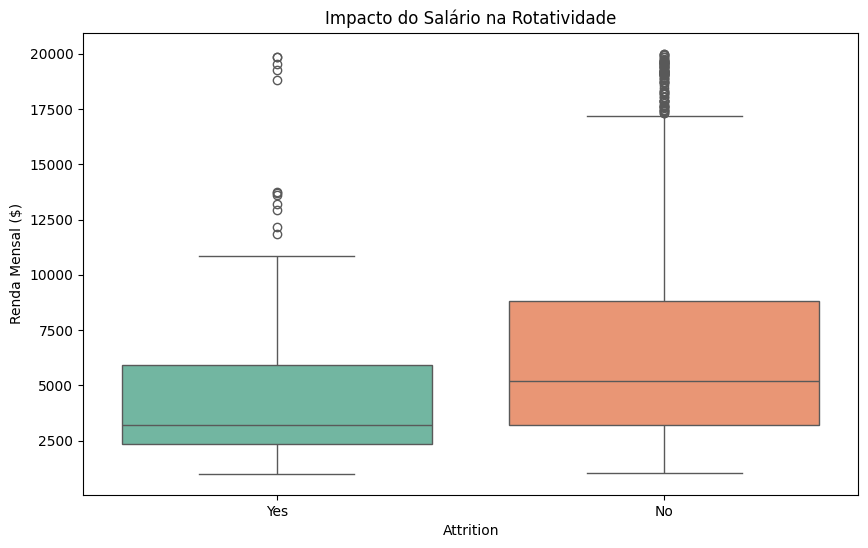

In [11]:
# Comparação direta das médias entre quem Saiu (Yes) e quem Ficou (No)
comparacao = funcionarios.groupby('Attrition')[['MonthlyIncome', 'Age']].mean()
print(comparacao)

# Visualização com Boxplot
# O gráfico mostra que a mediana salarial de quem sai (laranja) é significativamente menor
plt.figure(figsize=(10, 6))
sns.boxplot(x='Attrition', y='MonthlyIncome', data=funcionarios, palette='Set2')

plt.title('Impacto do Salário na Rotatividade')
plt.ylabel('Renda Mensal ($)')
plt.show()

## 4. Mapa de Correlação (Heatmap)
Para identificar outros fatores além do salário, geramos uma Matriz de Correlação.
Focamos na linha `Attrition_Numerico` para ver quais variáveis têm correlação positiva (vermelho) ou negativa (azul).

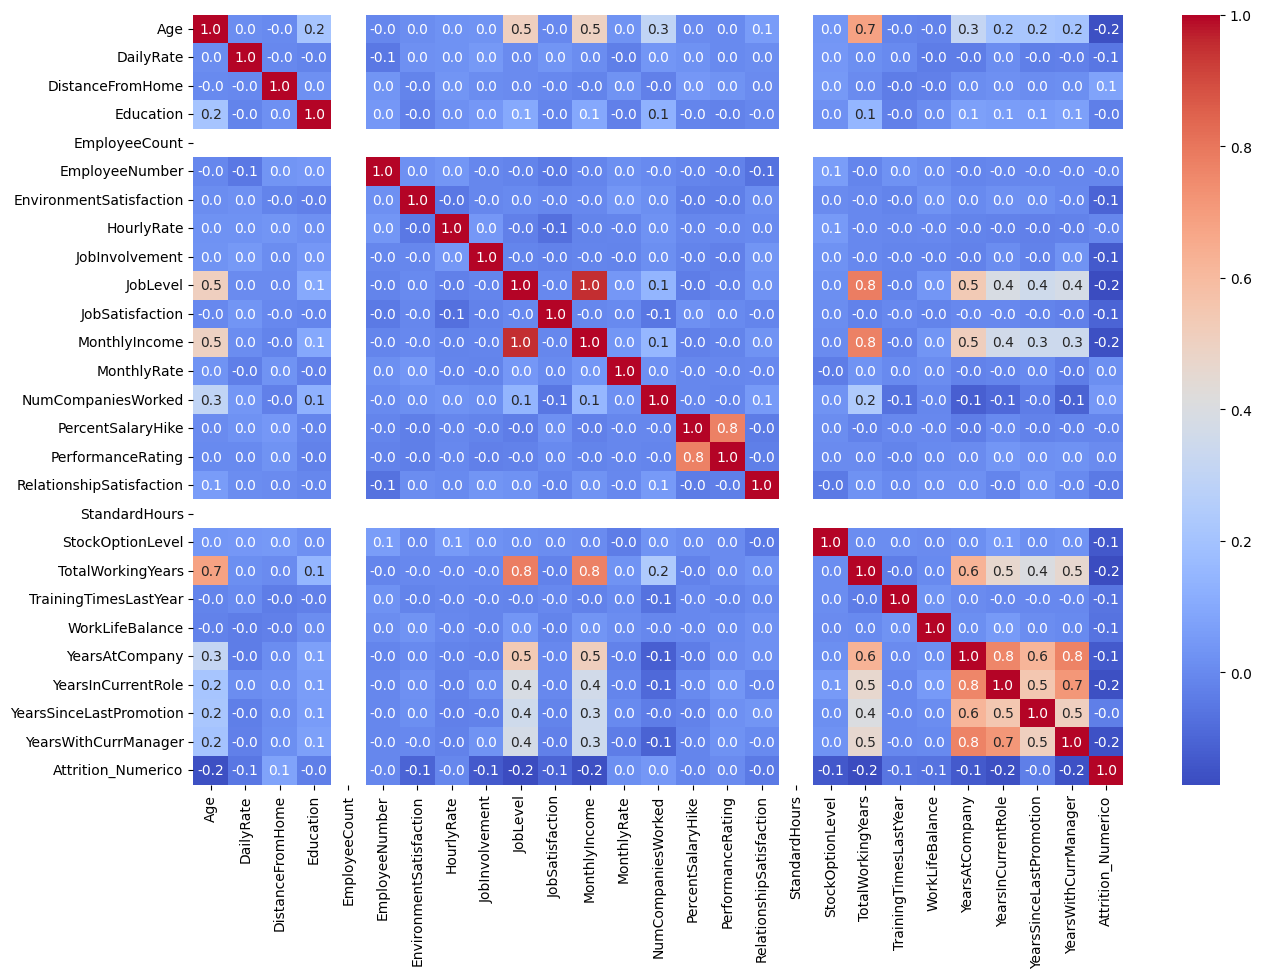

In [12]:
# Ajustando o tamanho da figura para melhor visualização
plt.figure(figsize=(15, 10))

# Selecionando apenas colunas numéricas (o .corr() não funciona com texto)
colunas_numericas = funcionarios.select_dtypes(include=['float64', 'int64'])

# Calculando a correlação de todas as variáveis entre si
correlacao = colunas_numericas.corr()

# Gerando o Heatmap
# annot=True mostra os números, cmap="coolwarm" destaca os extremos (azul/vermelho)
sns.heatmap(correlacao, annot=True, fmt=".1f", cmap="coolwarm")
plt.show()

## 5. Insights e Conclusões
Baseado no mapa de calor e nas análises anteriores, identificamos os principais drivers de retenção:

1.  **Fator Idade e Tempo (`Age`, `TotalWorkingYears`):** Correlação negativa forte. Funcionários mais jovens e com menos tempo de carreira tendem a sair mais. O risco diminui conforme a senioridade aumenta.
2.  **Zona de Risco:** Os primeiros anos (`YearsAtCompany`) são críticos. A empresa deve focar esforços de retenção no *onboarding* e nos 2 primeiros anos.
3.  **Stock Options (`StockOptionLevel`):** Correlação negativa relevante. Funcionários com opções de ações raramente saem, indicando ser uma ferramenta eficaz de retenção ("Algemas de Ouro").